# XGBoost Forecasting Pipeline

This notebook mirrors the same parquet input, target definition, chronological split, evaluation metrics, and threshold backtest used in `vanilla_LSTM.ipynb`, `mlp.ipynb`, and `rnn.ipynb`, but replaces the neural model with an `XGBoost` regressor.

Baseline assumption: each timestamp row is treated as one tabular sample, similar to the MLP notebook, rather than a 60-step sequence. That keeps the task identical while giving you a simpler non-neural baseline.


In [10]:
# ==========================================
# 1. Imports
# ==========================================
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor

plt.style.use("seaborn-v0_8-whitegrid")


In [11]:
# ==========================================
# 2. Config
# ==========================================
CONFIG = {
    "data_path": "../data/LSTM_DATA_WITH_PRICE.parquet",
    "target_candidates": ["Target_5s_Return", "future_return_5s"],
    "seed": 42,
    "test_quantile": 0.85,
    "val_quantile_within_base": 0.85,
    "clip_val": 10.0,
    "learning_rate": 0.03,
    "n_estimators": 800,
    "max_depth": 6,
    "min_child_weight": 10,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "gamma": 0.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "max_bin": 256,
    "early_stopping_rounds": 50,
    "eval_metrics": ["rmse", "mae"],
    "importance_type": "gain",
    "n_jobs": -1,
    "verbose_eval": False,
    "taker_fee_rate": 0.072,
    "upper_quantile": 0.90,
    "lower_quantile": 0.10,
    "direction_epsilon": 1e-5,
    "model_path": "../models/best_alpha_xgboost.json",
}


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(CONFIG["seed"])

print(f"XGBoost version: {xgb.__version__}")
print(f"Model checkpoint: {Path(CONFIG['model_path']).resolve()}")
print(f"Data path: {Path(CONFIG['data_path']).resolve()}")


XGBoost version: 2.1.1
Model checkpoint: /Users/moryshi/Projects/fintech/540 Machine Learning/PolyMarket analysis - inverse reinforcement learning/models/best_alpha_xgboost.json
Data path: /Users/moryshi/Projects/fintech/540 Machine Learning/PolyMarket analysis - inverse reinforcement learning/data/LSTM_DATA_WITH_PRICE.parquet


In [12]:
# ==========================================
# 3. Data loading
# Same parquet source and backtest metadata logic as the
# LSTM / MLP / RNN notebooks.
# ==========================================
data_path = Path(CONFIG["data_path"])
if not data_path.exists():
    raise FileNotFoundError(f"Could not find parquet file: {data_path.resolve()}")

try:
    data = pd.read_parquet(data_path).copy()
except ImportError as exc:
    raise ImportError(
        "Reading the parquet file requires `pyarrow` or `fastparquet` in the active notebook kernel."
    ) from exc

required_cols = {"slug", "timestamp"}
missing_required = sorted(required_cols.difference(data.columns))
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

TARGET_COL = next((col for col in CONFIG["target_candidates"] if col in data.columns), None)
if TARGET_COL is None:
    raise KeyError(f"Could not find target column. Tried: {CONFIG['target_candidates']}")

data["timestamp"] = pd.to_datetime(data["timestamp"])
data = data.sort_values(["timestamp", "slug"]).reset_index(drop=True)

execution_price_candidates = [
    "execution_price",
    "Up_Mid_Price",
    "price",
    "Up_trade_close",
    "Up_micro_price",
]
execution_price_col = next((col for col in execution_price_candidates if col in data.columns), None)
if execution_price_col is None:
    print(
        "Warning: no execution price column found. Backtest metadata will keep an "
        "execution_price field, but values will be NaN until the parquet includes price data."
    )
else:
    print(f"Execution price source column: {execution_price_col}")

meta_cols = ["slug", "timestamp", TARGET_COL]
if execution_price_col is not None:
    meta_cols.append(execution_price_col)
feature_cols = [col for col in data.columns if col not in meta_cols]

if not feature_cols:
    raise ValueError(
        "No feature columns found after excluding slug, timestamp, target, and execution price."
    )

non_numeric_features = data[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_features:
    raise TypeError(f"All XGBoost features must be numeric. Found: {non_numeric_features[:10]}")

missing_model_rows = int(data[feature_cols + [TARGET_COL]].isna().any(axis=1).sum())
if missing_model_rows:
    raise ValueError(
        f"Found {missing_model_rows} rows with missing features or target in the parquet data."
    )

print(f"Loaded shape: {data.shape}")
print(f"Target column: {TARGET_COL}")
print(f"Feature count: {len(feature_cols)}")
print(f"Unique contracts: {data['slug'].nunique()}")
print(f"Timestamp range: {data['timestamp'].min()} -> {data['timestamp'].max()}")

preview_cols = ["slug", "timestamp", TARGET_COL]
if execution_price_col is not None:
    preview_cols.append(execution_price_col)
preview_cols += feature_cols[:5]
print(data[preview_cols].head())


Execution price source column: execution_price
Loaded shape: (450747, 25)
Target column: Target_5s_Return
Feature count: 21
Unique contracts: 657
Timestamp range: 2025-12-01 06:01:31+00:00 -> 2025-12-15 03:14:24+00:00
                        slug                 timestamp  Target_5s_Return  \
0  btc-updown-15m-1764568800 2025-12-01 06:01:31+00:00          0.062893   
1  btc-updown-15m-1764568800 2025-12-01 06:01:32+00:00          0.037037   
2  btc-updown-15m-1764568800 2025-12-01 06:01:33+00:00          0.024540   
3  btc-updown-15m-1764568800 2025-12-01 06:01:34+00:00          0.000000   
4  btc-updown-15m-1764568800 2025-12-01 06:01:35+00:00          0.018293   

   execution_price   moneyness  time_to_expiry  Micro_Price_Imbalance  \
0            0.795  140.658783           809.0              -0.001939   
1            0.810  140.658783           808.0              -0.002684   
2            0.815  145.819987           807.0              -0.002711   
3            0.815  146.008138   

In [13]:
# ==========================================
# 4. Chronological split
# Keep the same split philosophy as the neural notebooks:
# - sort globally by timestamp
# - latest 15% stays as test
# - train / validation only come from earlier data
# ==========================================
test_cutoff = data["timestamp"].quantile(CONFIG["test_quantile"])

df_base = data[data["timestamp"] <= test_cutoff].copy()
df_test = data[data["timestamp"] > test_cutoff].copy()

val_cutoff = df_base["timestamp"].quantile(CONFIG["val_quantile_within_base"])
df_train = df_base[df_base["timestamp"] <= val_cutoff].copy()
df_val = df_base[df_base["timestamp"] > val_cutoff].copy()

split_frames = {
    "train": df_train,
    "val": df_val,
    "test": df_test,
}

for split_name, frame in split_frames.items():
    if frame.empty:
        raise ValueError(f"{split_name} split is empty. Adjust the time split configuration.")

print(f"Base size (train + val): {len(df_base):,}")
print(f"Train size: {len(df_train):,}")
print(f"Val size:   {len(df_val):,}")
print(f"Test size:  {len(df_test):,}")
print(f"Train range: {df_train['timestamp'].min()} -> {df_train['timestamp'].max()}")
print(f"Val range:   {df_val['timestamp'].min()} -> {df_val['timestamp'].max()}")
print(f"Test range:  {df_test['timestamp'].min()} -> {df_test['timestamp'].max()}")
print(
    "Unique contracts | "
    f"Train: {df_train['slug'].nunique()} | "
    f"Val: {df_val['slug'].nunique()} | "
    f"Test: {df_test['slug'].nunique()}"
)


Base size (train + val): 383,135
Train size: 325,664
Val size:   57,471
Test size:  67,612
Train range: 2025-12-01 06:01:31+00:00 -> 2025-12-12 11:37:08+00:00
Val range:   2025-12-12 11:37:09+00:00 -> 2025-12-13 17:02:57+00:00
Test range:  2025-12-13 17:02:58+00:00 -> 2025-12-15 03:14:24+00:00
Unique contracts | Train: 480 | Val: 83 | Test: 96


In [14]:
# ==========================================
# 5. Scaling and tabular sample construction
# Tree models do not strictly need scaling, but we keep the
# same train-fit / val-test-transform pipeline as MLP/RNN/LSTM
# so the baseline stays comparable.
# ==========================================
scaler = RobustScaler()
CLIP_VAL = CONFIG["clip_val"]

df_train.loc[:, feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val.loc[:, feature_cols] = scaler.transform(df_val[feature_cols])
df_test.loc[:, feature_cols] = scaler.transform(df_test[feature_cols])

for frame in (df_train, df_val, df_test):
    frame.loc[:, feature_cols] = np.clip(frame[feature_cols], -CLIP_VAL, CLIP_VAL)


def create_tabular_samples(df, feature_cols, target_col, execution_price_col=None):
    X = df[feature_cols].to_numpy(dtype=np.float32)
    y = df[target_col].to_numpy(dtype=np.float32)

    meta_cols = ["slug", "timestamp"]
    if execution_price_col is not None and execution_price_col in df.columns:
        meta_cols.append(execution_price_col)

    meta = df[meta_cols].reset_index(drop=True).copy()
    if execution_price_col is not None and execution_price_col in meta.columns:
        meta = meta.rename(columns={execution_price_col: "execution_price"})
    else:
        meta["execution_price"] = np.nan

    return X, y, meta


X_train_np, y_train_np, meta_train = create_tabular_samples(
    df_train,
    feature_cols,
    TARGET_COL,
    execution_price_col=execution_price_col,
)
X_val_np, y_val_np, meta_val = create_tabular_samples(
    df_val,
    feature_cols,
    TARGET_COL,
    execution_price_col=execution_price_col,
)
X_test_np, y_test_np, meta_test = create_tabular_samples(
    df_test,
    feature_cols,
    TARGET_COL,
    execution_price_col=execution_price_col,
)

print("Each row is treated as one tabular sample.")
print(f"X_train shape: {X_train_np.shape}")
print(f"X_val shape:   {X_val_np.shape}")
print(f"X_test shape:  {X_test_np.shape}")


Each row is treated as one tabular sample.
X_train shape: (325664, 21)
X_val shape:   (57471, 21)
X_test shape:  (67612, 21)


In [15]:
# ==========================================
# 6. XGBoost baseline
# Train on tabular rows and use validation MAE for early
# stopping while keeping the same downstream metrics.
# ==========================================
xgb_sklearn_params = {
    "objective": "reg:squarederror",
    "learning_rate": CONFIG["learning_rate"],
    "n_estimators": CONFIG["n_estimators"],
    "max_depth": CONFIG["max_depth"],
    "min_child_weight": CONFIG["min_child_weight"],
    "subsample": CONFIG["subsample"],
    "colsample_bytree": CONFIG["colsample_bytree"],
    "gamma": CONFIG["gamma"],
    "reg_alpha": CONFIG["reg_alpha"],
    "reg_lambda": CONFIG["reg_lambda"],
    "tree_method": CONFIG["tree_method"],
    "max_bin": CONFIG["max_bin"],
    "random_state": CONFIG["seed"],
    "n_jobs": CONFIG["n_jobs"],
    "early_stopping_rounds": CONFIG["early_stopping_rounds"],
    "eval_metric": CONFIG["eval_metrics"],
    "importance_type": CONFIG["importance_type"],
}

model_api = "sklearn"

try:
    model = XGBRegressor(**xgb_sklearn_params)
    model.fit(
        X_train_np,
        y_train_np,
        eval_set=[(X_train_np, y_train_np), (X_val_np, y_val_np)],
        verbose=CONFIG["verbose_eval"],
    )
    history = model.evals_result()
    best_iteration = getattr(model, "best_iteration", None)
    best_score = getattr(model, "best_score", None)
except AttributeError as exc:
    if "__sklearn_tags__" not in str(exc):
        raise
    print("Detected sklearn tag compatibility issue; falling back to native xgboost.train API.")
    model_api = "native"
    native_params = {
        "objective": "reg:squarederror",
        "eta": CONFIG["learning_rate"],
        "max_depth": CONFIG["max_depth"],
        "min_child_weight": CONFIG["min_child_weight"],
        "subsample": CONFIG["subsample"],
        "colsample_bytree": CONFIG["colsample_bytree"],
        "gamma": CONFIG["gamma"],
        "alpha": CONFIG["reg_alpha"],
        "lambda": CONFIG["reg_lambda"],
        "tree_method": CONFIG["tree_method"],
        "max_bin": CONFIG["max_bin"],
        "seed": CONFIG["seed"],
        "nthread": CONFIG["n_jobs"],
        "eval_metric": CONFIG["eval_metrics"],
    }
    dtrain = xgb.DMatrix(X_train_np, label=y_train_np, feature_names=feature_cols)
    dval = xgb.DMatrix(X_val_np, label=y_val_np, feature_names=feature_cols)
    evals_result = {}
    model = xgb.train(
        params=native_params,
        dtrain=dtrain,
        num_boost_round=CONFIG["n_estimators"],
        evals=[(dtrain, "validation_0"), (dval, "validation_1")],
        early_stopping_rounds=CONFIG["early_stopping_rounds"],
        evals_result=evals_result,
        verbose_eval=CONFIG["verbose_eval"],
    )
    history = evals_result
    best_iteration = getattr(model, "best_iteration", None)
    if best_iteration is not None and "validation_1" in history:
        primary_metric = CONFIG["eval_metrics"][0]
        best_score = history["validation_1"][primary_metric][best_iteration]
    else:
        best_score = None

model.save_model(CONFIG["model_path"])

print("Training complete.")
print(f"Training API: {model_api}")
print(f"Saved model to: {Path(CONFIG['model_path']).resolve()}")
if best_iteration is not None:
    print(f"Best boosting round: {best_iteration}")
if best_score is not None:
    print(f"Best validation score: {best_score}")


Training complete.
Training API: sklearn
Saved model to: /Users/moryshi/Projects/fintech/540 Machine Learning/PolyMarket analysis - inverse reinforcement learning/models/best_alpha_xgboost.json
Best boosting round: 0
Best validation score: 0.06049242912146318


In [16]:
# ==========================================
# 7. Evaluation
# Standard regression metrics plus finance-oriented ICs.
# ==========================================
def load_best_model(model_path):
    # Try sklearn wrapper first; if the local sklearn/xgboost pair is
    # incompatible, fall back to raw Booster.
    try:
        candidate = XGBRegressor()
        candidate.load_model(model_path)
        _ = candidate.get_booster()
        return candidate, "sklearn"
    except Exception:
        booster = xgb.Booster()
        booster.load_model(model_path)
        return booster, "native"


best_model, model_api_inference = load_best_model(CONFIG["model_path"])
print(f"Inference API: {model_api_inference}")


def safe_pearson_ic(preds, targets):
    try:
        value, _ = pearsonr(preds, targets)
    except Exception:
        value = np.nan
    return 0.0 if np.isnan(value) else float(value)


def safe_rank_ic(preds, targets):
    try:
        value, _ = spearmanr(preds, targets)
    except Exception:
        value = np.nan
    return 0.0 if np.isnan(value) else float(value)


def regression_report(targets, preds, split_name):
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mae = mean_absolute_error(targets, preds)
    r2 = r2_score(targets, preds)
    pearson_ic = safe_pearson_ic(preds, targets)
    rank_ic = safe_rank_ic(preds, targets)

    valid_idx = np.abs(targets) > CONFIG["direction_epsilon"]
    directional_accuracy = (
        np.mean(np.sign(preds[valid_idx]) == np.sign(targets[valid_idx]))
        if valid_idx.any()
        else np.nan
    )

    metrics = {
        "split": split_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "directional_accuracy": directional_accuracy,
    }

    print()
    print("=" * 60)
    print(f"{split_name} metrics")
    print("=" * 60)
    print(f"RMSE:                 {rmse:.6f}")
    print(f"MAE:                  {mae:.6f}")
    print(f"R^2:                  {r2:.6f}")
    print(f"Pearson IC:           {pearson_ic:.4f}")
    print(f"Rank IC:              {rank_ic:.4f}")
    print(f"Directional accuracy: {directional_accuracy:.2%}")
    return metrics


def model_predict(model, X, feature_names=None):
    if isinstance(model, xgb.Booster):
        dmat = xgb.DMatrix(X, feature_names=feature_names)
        best_iter = getattr(model, "best_iteration", None)
        if best_iter is not None and best_iter >= 0:
            return model.predict(dmat, iteration_range=(0, best_iter + 1))
        return model.predict(dmat)
    return model.predict(X)


val_preds = model_predict(best_model, X_val_np, feature_names=feature_cols)
test_preds = model_predict(best_model, X_test_np, feature_names=feature_cols)
val_targets = y_val_np.copy()
test_targets = y_test_np.copy()

all_val_preds = val_preds.tolist()
all_val_targets = val_targets.tolist()
all_test_preds = test_preds.tolist()
all_test_targets = test_targets.tolist()

val_results_df = meta_val.copy()
val_results_df["pred_signal"] = np.asarray(val_preds, dtype=np.float32)
val_results_df["future_return"] = np.asarray(val_targets, dtype=np.float32)
val_results_df = val_results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True)

test_results_df = meta_test.copy()
test_results_df["pred_signal"] = np.asarray(test_preds, dtype=np.float32)
test_results_df["future_return"] = np.asarray(test_targets, dtype=np.float32)
raw_test_results_are_chronological = test_results_df["timestamp"].is_monotonic_increasing
test_results_df = test_results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True)

print(f"Raw tabular output already chronological: {raw_test_results_are_chronological}")
if test_results_df["execution_price"].isna().all():
    print("Warning: execution_price is all NaN in test_results_df.")
else:
    print(
        "Execution price non-null samples: "
        f"{test_results_df['execution_price'].notna().sum()} / {len(test_results_df)}"
    )

val_metrics = regression_report(val_targets, val_preds, "Validation")
test_metrics = regression_report(test_targets, test_preds, "Test")

metrics_df = pd.DataFrame([val_metrics, test_metrics])
metrics_df


Inference API: native
Raw tabular output already chronological: True
Execution price non-null samples: 67612 / 67612

Validation metrics
RMSE:                 0.179912
MAE:                  0.060492
R^2:                  0.001633
Pearson IC:           0.0647
Rank IC:              0.1386
Directional accuracy: 51.00%

Test metrics
RMSE:                 0.327701
MAE:                  0.070471
R^2:                  0.000590
Pearson IC:           0.0276
Rank IC:              0.1223
Directional accuracy: 50.77%


,split,rmse,mae,r2,pearson_ic,rank_ic,directional_accuracy
0,Validation,0.179912,0.060492,0.001633,0.064663,0.138628,0.510018
1,Test,0.327701,0.070471,0.000590,0.027631,0.122322,0.507738


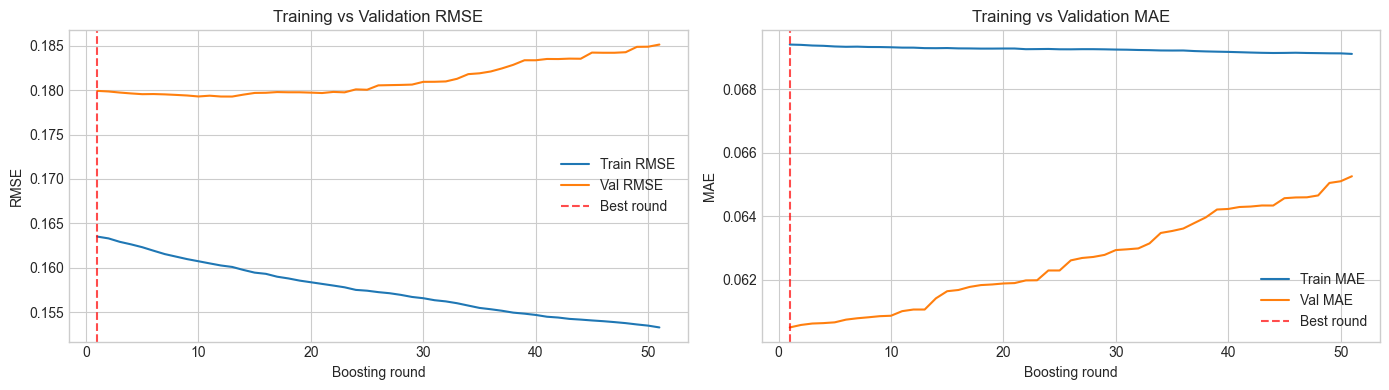

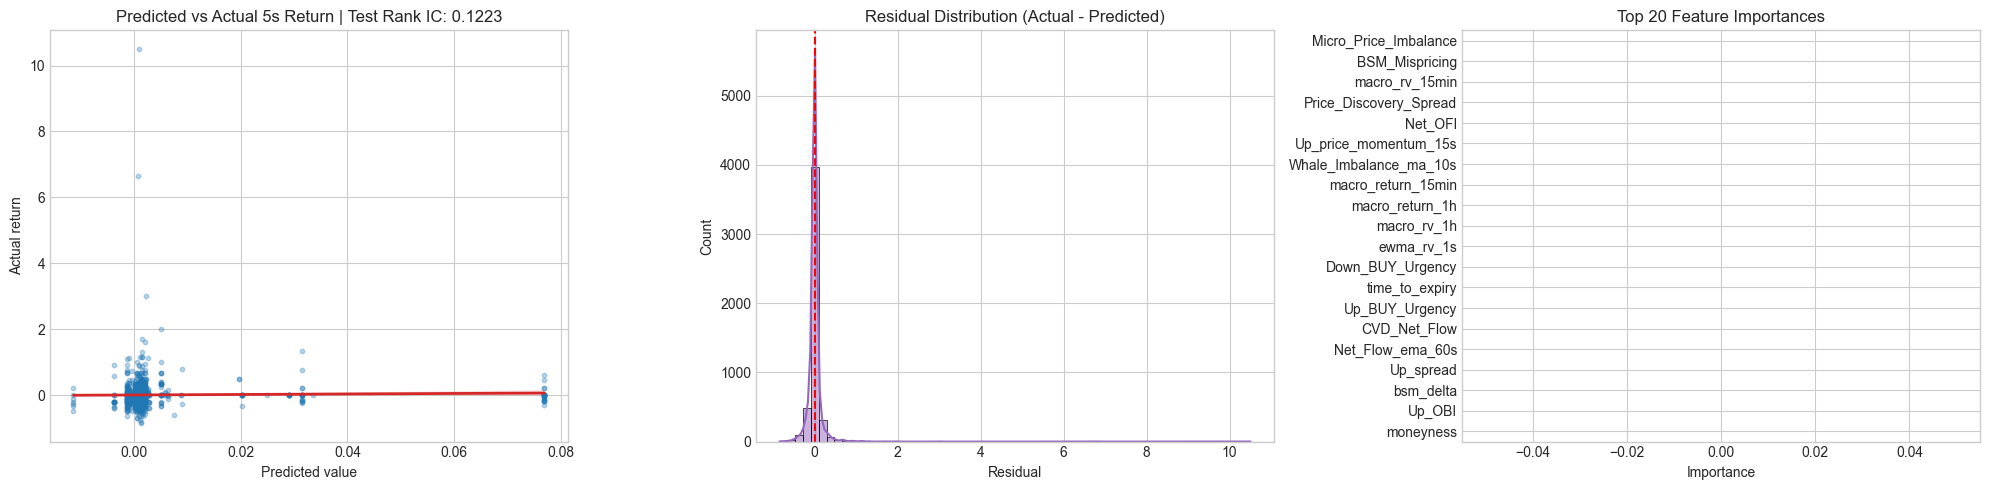

,importance
moneyness,0.0
Up_OBI,0.0
BSM_Mispricing,0.0
macro_rv_15min,0.0
Price_Discovery_Spread,0.0
Net_OFI,0.0
Up_price_momentum_15s,0.0
Whale_Imbalance_ma_10s,0.0
macro_return_15min,0.0
macro_return_1h,0.0


In [17]:
# ==========================================
# 8. Diagnostics
# Plot learning curves, prediction diagnostics, and feature
# importances for the tabular baseline.
# ==========================================
history_df = pd.DataFrame(
    {
        "train_rmse": history["validation_0"]["rmse"],
        "val_rmse": history["validation_1"]["rmse"],
        "train_mae": history["validation_0"]["mae"],
        "val_mae": history["validation_1"]["mae"],
    }
)

best_iter_for_plot = getattr(best_model, "best_iteration", None)
best_round_for_plot = None if best_iter_for_plot is None else best_iter_for_plot + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_df.index + 1, history_df["train_rmse"], label="Train RMSE")
axes[0].plot(history_df.index + 1, history_df["val_rmse"], label="Val RMSE")
if best_round_for_plot is not None:
    axes[0].axvline(best_round_for_plot, color="red", linestyle="--", alpha=0.7, label="Best round")
axes[0].set_title("Training vs Validation RMSE")
axes[0].set_xlabel("Boosting round")
axes[0].set_ylabel("RMSE")
axes[0].legend()

axes[1].plot(history_df.index + 1, history_df["train_mae"], label="Train MAE")
axes[1].plot(history_df.index + 1, history_df["val_mae"], label="Val MAE")
if best_round_for_plot is not None:
    axes[1].axvline(best_round_for_plot, color="red", linestyle="--", alpha=0.7, label="Best round")
axes[1].set_title("Training vs Validation MAE")
axes[1].set_xlabel("Boosting round")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()

sample_size = min(5000, len(test_preds))
sample_idx = np.random.choice(len(test_preds), sample_size, replace=False)
residuals = test_targets - test_preds

if hasattr(best_model, "feature_importances_"):
    importance_series = pd.Series(best_model.feature_importances_, index=feature_cols, name="importance")
else:
    score_map = best_model.get_score(importance_type=CONFIG["importance_type"])
    importance_series = pd.Series(
        {feature: float(score_map.get(feature, 0.0)) for feature in feature_cols},
        name="importance",
    )

feature_importance_df = (
    importance_series.sort_values(ascending=False)
    .head(20)
    .sort_values()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.regplot(
    x=test_preds[sample_idx],
    y=test_targets[sample_idx],
    ax=axes[0],
    scatter_kws={"alpha": 0.3, "s": 10, "color": "#1f77b4"},
    line_kws={"color": "#d62728", "linewidth": 2},
)
axes[0].set_title(f"Predicted vs Actual 5s Return | Test Rank IC: {test_metrics['rank_ic']:.4f}")
axes[0].set_xlabel("Predicted value")
axes[0].set_ylabel("Actual return")

sns.histplot(residuals[sample_idx], bins=60, kde=True, color="#9467bd", ax=axes[1])
axes[1].axvline(0.0, color="red", linestyle="--")
axes[1].set_title("Residual Distribution (Actual - Predicted)")
axes[1].set_xlabel("Residual")

feature_importance_df.plot(kind="barh", color="#2ca02c", ax=axes[2])
axes[2].set_title("Top 20 Feature Importances")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.show()

feature_importance_df.to_frame().sort_values("importance", ascending=False).head(10)



Test backtest summary
total_samples: 67612
time_start: 2025-12-13 17:02:58+00:00
time_end: 2025-12-15 03:14:24+00:00
n_trades: 18105
trade_rate: 26.78%
n_long: 10483
n_short: 7622
signal_hit_rate: 39.03%
win_rate: 42.72%
gross_pnl_sum: 534.709012
trade_cost_sum: 158.721998
net_pnl_sum: 375.987015
avg_net_pnl_per_trade: 0.020767
avg_abs_prediction_traded: 0.0030148709192872047
upper_threshold: 0.001483
lower_threshold: 0.000837
execution_price_non_null: 67612


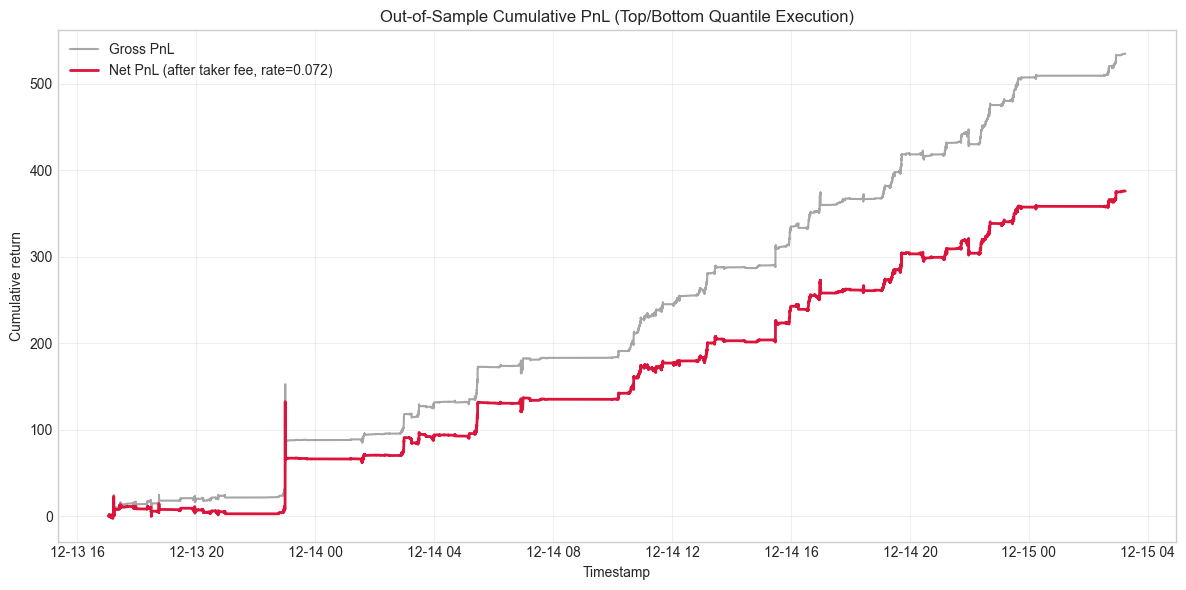

,slug,timestamp,execution_price,pred_signal,future_return,position,shares_traded,gross_pnl,trade_cost,net_pnl
51,btc-updown-15m-1765645200,2025-12-13 17:03:49+00:00,0.175,0.002129,-0.057143,1,1.0,-0.057143,0.010395,-0.067538
52,btc-updown-15m-1765645200,2025-12-13 17:03:50+00:00,0.170,0.002129,-0.088235,1,1.0,-0.088235,0.010159,-0.098394
54,btc-updown-15m-1765645200,2025-12-13 17:03:52+00:00,0.160,0.002129,0.000000,1,1.0,0.000000,0.009677,-0.009677
55,btc-updown-15m-1765645200,2025-12-13 17:03:53+00:00,0.155,0.002129,0.032258,1,1.0,0.032258,0.009430,0.022828
56,btc-updown-15m-1765645200,2025-12-13 17:03:54+00:00,0.165,0.002129,0.363636,1,1.0,0.363636,0.009920,0.353717


In [18]:
# ==========================================
# 9. Threshold-based backtest
# Same backtest accounting and chronology checks as the
# updated LSTM / MLP / RNN notebooks.
# ==========================================
TAKER_FEE_RATE = CONFIG["taker_fee_rate"]
UPPER_QUANTILE = CONFIG["upper_quantile"]
LOWER_QUANTILE = CONFIG["lower_quantile"]


def run_threshold_backtest(
    results_df,
    upper_quantile=0.90,
    lower_quantile=0.10,
    taker_fee_rate=0.072,
):
    bt_df = results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True).copy()
    bt_df["execution_price"] = pd.to_numeric(bt_df["execution_price"], errors="coerce")

    if bt_df["execution_price"].isna().any():
        missing_count = int(bt_df["execution_price"].isna().sum())
        raise ValueError(
            f"execution_price has {missing_count} missing values. Please confirm ../data/LSTM_DATA_WITH_PRICE.parquet includes price data."
        )

    upper_threshold = bt_df["pred_signal"].quantile(upper_quantile)
    lower_threshold = bt_df["pred_signal"].quantile(lower_quantile)

    bt_df["position"] = 0
    bt_df.loc[bt_df["pred_signal"] >= upper_threshold, "position"] = 1
    bt_df.loc[bt_df["pred_signal"] <= lower_threshold, "position"] = -1

    bt_df["shares_traded"] = np.abs(bt_df["position"]).astype(float)
    bt_df["gross_pnl"] = bt_df["position"] * bt_df["future_return"]
    bt_df["trade_cost"] = (
        bt_df["shares_traded"]
        * taker_fee_rate
        * bt_df["execution_price"]
        * (1.0 - bt_df["execution_price"])
    )
    bt_df["net_pnl"] = bt_df["gross_pnl"] - bt_df["trade_cost"]

    trades_only = bt_df[bt_df["position"] != 0].copy()

    signal_hit_rate = (
        np.mean(np.sign(trades_only["pred_signal"]) == np.sign(trades_only["future_return"]))
        if len(trades_only) > 0
        else np.nan
    )
    win_rate = (trades_only["net_pnl"] > 0).mean() if len(trades_only) > 0 else np.nan

    summary = {
        "total_samples": len(bt_df),
        "time_start": bt_df["timestamp"].min(),
        "time_end": bt_df["timestamp"].max(),
        "n_trades": len(trades_only),
        "trade_rate": len(trades_only) / len(bt_df) if len(bt_df) > 0 else np.nan,
        "n_long": int((trades_only["position"] == 1).sum()),
        "n_short": int((trades_only["position"] == -1).sum()),
        "signal_hit_rate": signal_hit_rate,
        "win_rate": win_rate,
        "gross_pnl_sum": bt_df["gross_pnl"].sum(),
        "trade_cost_sum": bt_df["trade_cost"].sum(),
        "net_pnl_sum": bt_df["net_pnl"].sum(),
        "avg_net_pnl_per_trade": trades_only["net_pnl"].mean() if len(trades_only) > 0 else np.nan,
        "avg_abs_prediction_traded": (
            trades_only["pred_signal"].abs().mean() if len(trades_only) > 0 else np.nan
        ),
        "upper_threshold": upper_threshold,
        "lower_threshold": lower_threshold,
        "execution_price_non_null": int(bt_df["execution_price"].notna().sum()),
    }

    return bt_df, trades_only, summary


bt_df, trades_only, bt_summary = run_threshold_backtest(
    test_results_df,
    upper_quantile=UPPER_QUANTILE,
    lower_quantile=LOWER_QUANTILE,
    taker_fee_rate=TAKER_FEE_RATE,
)

print()
print("=" * 60)
print("Test backtest summary")
print("=" * 60)
for key, value in bt_summary.items():
    if isinstance(value, float):
        if "rate" in key or "hit" in key or "win" in key:
            print(f"{key}: {value:.2%}")
        else:
            print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")

backtest_dataset = bt_df.copy()

plt.figure(figsize=(12, 6))
plt.plot(bt_df["timestamp"], bt_df["gross_pnl"].cumsum(), label="Gross PnL", color="gray", alpha=0.7)
plt.plot(
    bt_df["timestamp"],
    bt_df["net_pnl"].cumsum(),
    label=f"Net PnL (after taker fee, rate={TAKER_FEE_RATE})",
    color="crimson",
    linewidth=2,
)
plt.title("Out-of-Sample Cumulative PnL (Top/Bottom Quantile Execution)")
plt.xlabel("Timestamp")
plt.ylabel("Cumulative return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

trades_only.head()


In [31]:
# ==========================================
# 9. Threshold-based backtest (revised)
# Fixed-count bucket selection + strategy-consistent metrics
# ==========================================
TAKER_FEE_RATE = CONFIG["taker_fee_rate"]
UPPER_QUANTILE = CONFIG["upper_quantile"]
LOWER_QUANTILE = CONFIG["lower_quantile"]


def _max_drawdown(cum_pnl: pd.Series) -> float:
    running_max = cum_pnl.cummax()
    drawdown = cum_pnl - running_max
    return float(drawdown.min()) if len(drawdown) > 0 else np.nan


def run_threshold_backtest(
    results_df,
    upper_quantile=0.90,
    lower_quantile=0.10,
    taker_fee_rate=0.072,
):
    bt_df = results_df.sort_values(["timestamp", "slug"]).reset_index(drop=True).copy()
    bt_df["execution_price"] = pd.to_numeric(bt_df["execution_price"], errors="coerce")

    if bt_df["execution_price"].isna().any():
        missing_count = int(bt_df["execution_price"].isna().sum())
        raise ValueError(
            f"execution_price has {missing_count} missing values. Please confirm price data exists."
        )

    n = len(bt_df)
    if n == 0:
        raise ValueError("results_df is empty.")

    # --------------------------------------------------
    # 1) Fixed-count selection instead of >= / <= quantile thresholds
    # This avoids tie inflation for discrete tree-model predictions.
    # --------------------------------------------------
    n_long = int(np.floor((1.0 - upper_quantile) * n))
    n_short = int(np.floor(lower_quantile * n))

    # Safety
    n_long = max(n_long, 0)
    n_short = max(n_short, 0)

    bt_df["position"] = 0

    # Rank-based selection with deterministic tie-breaking by original order
    long_idx = (
        bt_df.sort_values(["pred_signal", "timestamp", "slug"], ascending=[False, True, True])
        .head(n_long)
        .index
    )
    short_idx = (
        bt_df.sort_values(["pred_signal", "timestamp", "slug"], ascending=[True, True, True])
        .head(n_short)
        .index
    )

    bt_df.loc[long_idx, "position"] = 1
    bt_df.loc[short_idx, "position"] = -1

    # Thresholds are now descriptive, not selection-defining
    upper_threshold = bt_df.loc[long_idx, "pred_signal"].min() if n_long > 0 else np.nan
    lower_threshold = bt_df.loc[short_idx, "pred_signal"].max() if n_short > 0 else np.nan

    # --------------------------------------------------
    # 2) PnL accounting
    # --------------------------------------------------
    bt_df["shares_traded"] = np.abs(bt_df["position"]).astype(float)
    bt_df["gross_pnl"] = bt_df["position"] * bt_df["future_return"]

    # IMPORTANT:
    # This fee formula assumes a prediction-market style fee proxy:
    # fee = rate * price * (1 - price) per traded share.
    # If your actual round-trip cost should include both entry and exit,
    # you may need to multiply this by 2.0.
    bt_df["trade_cost"] = (
        bt_df["shares_traded"]
        * taker_fee_rate
        * bt_df["execution_price"]
        * (1.0 - bt_df["execution_price"])
    )

    bt_df["net_pnl"] = bt_df["gross_pnl"] - 2 * bt_df["trade_cost"]

    trades_only = bt_df[bt_df["position"] != 0].copy()

    # --------------------------------------------------
    # 3) Strategy-consistent hit rates
    # --------------------------------------------------
    strategy_hit_rate = (
        np.mean(np.sign(trades_only["position"]) == np.sign(trades_only["future_return"]))
        if len(trades_only) > 0
        else np.nan
    )

    long_hit_rate = (
        (trades_only.loc[trades_only["position"] == 1, "future_return"] > 0).mean()
        if (trades_only["position"] == 1).any()
        else np.nan
    )

    short_hit_rate = (
        (trades_only.loc[trades_only["position"] == -1, "future_return"] < 0).mean()
        if (trades_only["position"] == -1).any()
        else np.nan
    )

    # Keep old metric too, but rename clearly because it is NOT strategy hit rate
    pred_sign_match_rate = (
        np.mean(np.sign(trades_only["pred_signal"]) == np.sign(trades_only["future_return"]))
        if len(trades_only) > 0
        else np.nan
    )

    win_rate = (trades_only["net_pnl"] > 0).mean() if len(trades_only) > 0 else np.nan

    # --------------------------------------------------
    # 4) Bucket economics
    # --------------------------------------------------
    long_mean_future_return = (
        trades_only.loc[trades_only["position"] == 1, "future_return"].mean()
        if (trades_only["position"] == 1).any()
        else np.nan
    )

    short_mean_future_return = (
        trades_only.loc[trades_only["position"] == -1, "future_return"].mean()
        if (trades_only["position"] == -1).any()
        else np.nan
    )

    long_short_spread_mean = (
        long_mean_future_return - short_mean_future_return
        if pd.notna(long_mean_future_return) and pd.notna(short_mean_future_return)
        else np.nan
    )

    long_avg_net_pnl = (
        trades_only.loc[trades_only["position"] == 1, "net_pnl"].mean()
        if (trades_only["position"] == 1).any()
        else np.nan
    )

    short_avg_net_pnl = (
        trades_only.loc[trades_only["position"] == -1, "net_pnl"].mean()
        if (trades_only["position"] == -1).any()
        else np.nan
    )

    # --------------------------------------------------
    # 5) Drawdown
    # --------------------------------------------------
    bt_df["gross_cum_pnl"] = bt_df["gross_pnl"].cumsum()
    bt_df["net_cum_pnl"] = bt_df["net_pnl"].cumsum()

    gross_max_drawdown = _max_drawdown(bt_df["gross_cum_pnl"])
    net_max_drawdown = _max_drawdown(bt_df["net_cum_pnl"])

    # --------------------------------------------------
    # 6) Diagnostics for ties / discreteness
    # --------------------------------------------------
    pred_unique_count = int(bt_df["pred_signal"].nunique())
    pred_positive_rate = float((bt_df["pred_signal"] > 0).mean())

    summary = {
        "total_samples": n,
        "time_start": bt_df["timestamp"].min(),
        "time_end": bt_df["timestamp"].max(),
        "n_trades": len(trades_only),
        "trade_rate": len(trades_only) / n if n > 0 else np.nan,
        "n_long": int((trades_only["position"] == 1).sum()),
        "n_short": int((trades_only["position"] == -1).sum()),
        "target_n_long": n_long,
        "target_n_short": n_short,
        "strategy_hit_rate": strategy_hit_rate,
        "long_hit_rate": long_hit_rate,
        "short_hit_rate": short_hit_rate,
        "pred_sign_match_rate": pred_sign_match_rate,
        "win_rate": win_rate,
        "gross_pnl_sum": bt_df["gross_pnl"].sum(),
        "trade_cost_sum": bt_df["trade_cost"].sum(),
        "net_pnl_sum": bt_df["net_pnl"].sum(),
        "avg_net_pnl_per_trade": trades_only["net_pnl"].mean() if len(trades_only) > 0 else np.nan,
        "avg_gross_pnl_per_trade": trades_only["gross_pnl"].mean() if len(trades_only) > 0 else np.nan,
        "avg_trade_cost_per_trade": trades_only["trade_cost"].mean() if len(trades_only) > 0 else np.nan,
        "avg_abs_prediction_traded": trades_only["pred_signal"].abs().mean() if len(trades_only) > 0 else np.nan,
        "long_mean_future_return": long_mean_future_return,
        "short_mean_future_return": short_mean_future_return,
        "long_short_spread_mean": long_short_spread_mean,
        "long_avg_net_pnl": long_avg_net_pnl,
        "short_avg_net_pnl": short_avg_net_pnl,
        "gross_max_drawdown": gross_max_drawdown,
        "net_max_drawdown": net_max_drawdown,
        "upper_threshold_descriptive": upper_threshold,
        "lower_threshold_descriptive": lower_threshold,
        "pred_unique_count": pred_unique_count,
        "pred_positive_rate": pred_positive_rate,
        "execution_price_non_null": int(bt_df["execution_price"].notna().sum()),
    }

    return bt_df, trades_only, summary


Test backtest summary
total_samples: 67612
time_start: 2025-12-13 17:02:58+00:00
time_end: 2025-12-15 03:14:24+00:00
n_trades: 13522
trade_rate: 20.00%
n_long: 6761
n_short: 6761
target_n_long: 6761
target_n_short: 6761
strategy_hit_rate: 46.64%
long_hit_rate: 39.79%
short_hit_rate: 53.50%
pred_sign_match_rate: 40.11%
win_rate: 40.50%
gross_pnl_sum: 483.414014
trade_cost_sum: 115.983794
net_pnl_sum: 251.446426
avg_net_pnl_per_trade: 0.018595
avg_gross_pnl_per_trade: 0.035750
avg_trade_cost_per_trade: 0.008577
avg_abs_prediction_traded: 0.0035750800743699074
long_mean_future_return: 0.05489426478743553
short_mean_future_return: -0.016606107354164124
long_short_spread_mean: 0.07150037586688995
long_avg_net_pnl: 0.037700
short_avg_net_pnl: -0.000509
gross_max_drawdown: -67.543478
net_max_drawdown: -73.341712
upper_threshold_descriptive: 0.0014834582107141614
lower_threshold_descriptive: 0.0008369000279344618
pred_unique_count: 49
pred_positive_rate: 96.33%
execution_price_non_null: 67612

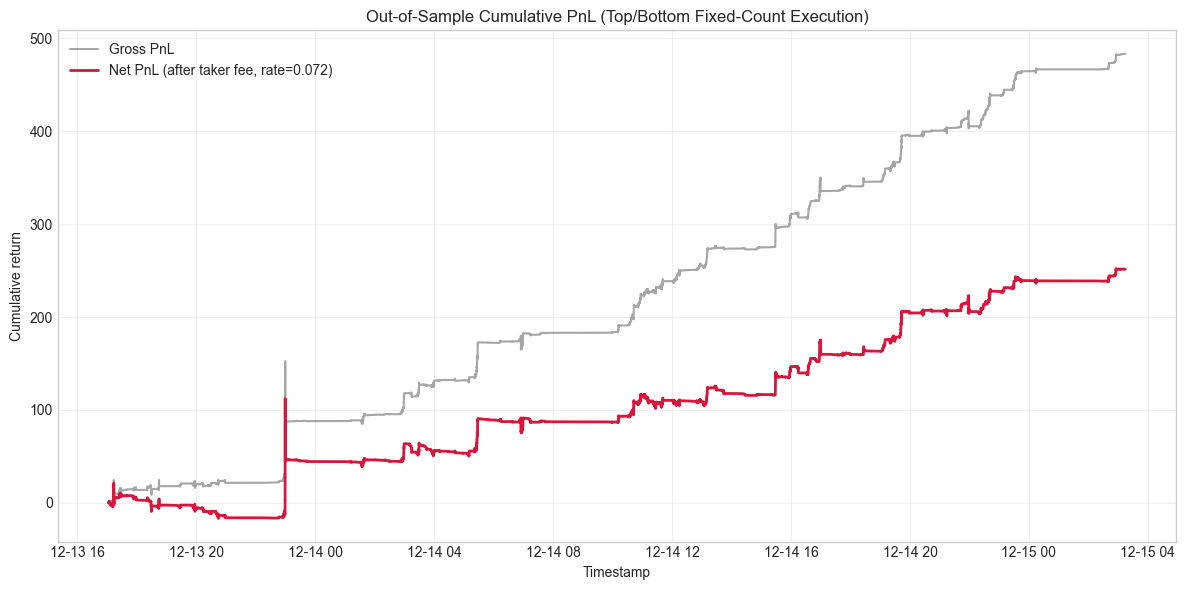

,slug,timestamp,execution_price,pred_signal,future_return,position,shares_traded,gross_pnl,trade_cost,net_pnl
51,btc-updown-15m-1765645200,2025-12-13 17:03:49+00:00,0.175,0.002129,-0.057143,1,1.0,-0.057143,0.010395,-0.077933
52,btc-updown-15m-1765645200,2025-12-13 17:03:50+00:00,0.170,0.002129,-0.088235,1,1.0,-0.088235,0.010159,-0.108554
54,btc-updown-15m-1765645200,2025-12-13 17:03:52+00:00,0.160,0.002129,0.000000,1,1.0,0.000000,0.009677,-0.019354
55,btc-updown-15m-1765645200,2025-12-13 17:03:53+00:00,0.155,0.002129,0.032258,1,1.0,0.032258,0.009430,0.013398
56,btc-updown-15m-1765645200,2025-12-13 17:03:54+00:00,0.165,0.002129,0.363636,1,1.0,0.363636,0.009920,0.343797


In [32]:
bt_df, trades_only, bt_summary = run_threshold_backtest(
    test_results_df,
    upper_quantile=UPPER_QUANTILE,
    lower_quantile=LOWER_QUANTILE,
    taker_fee_rate=TAKER_FEE_RATE,
)

print()
print("=" * 60)
print("Test backtest summary")
print("=" * 60)
for key, value in bt_summary.items():
    if isinstance(value, float):
        if any(tag in key for tag in ["rate", "hit", "win"]):
            print(f"{key}: {value:.2%}")
        else:
            print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")

backtest_dataset = bt_df.copy()

plt.figure(figsize=(12, 6))
plt.plot(bt_df["timestamp"], bt_df["gross_cum_pnl"], label="Gross PnL", color="gray", alpha=0.7)
plt.plot(
    bt_df["timestamp"],
    bt_df["net_cum_pnl"],
    label=f"Net PnL (after taker fee, rate={TAKER_FEE_RATE})",
    color="crimson",
    linewidth=2,
)
plt.title("Out-of-Sample Cumulative PnL (Top/Bottom Fixed-Count Execution)")
plt.xlabel("Timestamp")
plt.ylabel("Cumulative return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

trades_only.head()

In [30]:
bt_summary

{'total_samples': 67612,
 'time_start': Timestamp('2025-12-13 17:02:58+0000', tz='UTC'),
 'time_end': Timestamp('2025-12-15 03:14:24+0000', tz='UTC'),
 'n_trades': 13522,
 'trade_rate': 0.19999408389043366,
 'n_long': 6761,
 'n_short': 6761,
 'target_n_long': 6761,
 'target_n_short': 6761,
 'strategy_hit_rate': 0.46642508504659075,
 'long_hit_rate': 0.39787013755361633,
 'short_hit_rate': 0.5349800325395652,
 'pred_sign_match_rate': 0.40112409406892474,
 'win_rate': 0.4049696790415619,
 'gross_pnl_sum': 483.4140143194236,
 'trade_cost_sum': 115.98379416,
 'net_pnl_sum': 251.44642599942364,
 'avg_net_pnl_per_trade': 0.01859535763935983,
 'avg_gross_pnl_per_trade': 0.03575018594286523,
 'avg_trade_cost_per_trade': 0.0085774141517527,
 'avg_abs_prediction_traded': 0.00357508,
 'long_mean_future_return': 0.054894265,
 'short_mean_future_return': -0.016606107,
 'long_short_spread_mean': 0.071500376,
 'long_avg_net_pnl': 0.03769984222255615,
 'short_avg_net_pnl': -0.0005091269438364915,
 'gr